🔍 Inspecting: test2017_000000163853.png


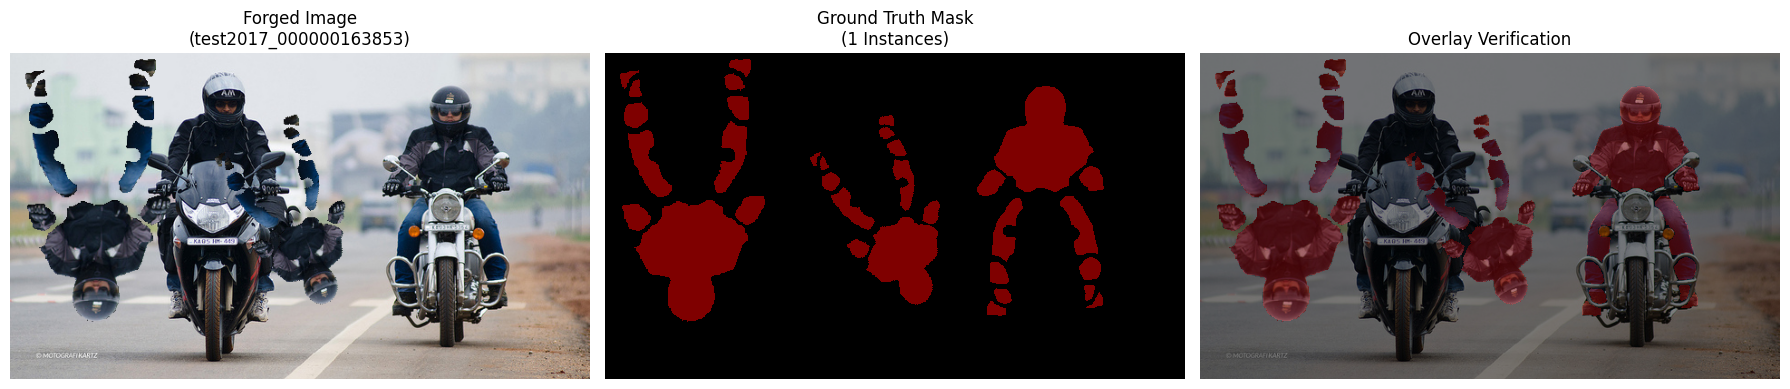

In [73]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib # Needed for the new colormap API
from PIL import Image
import json
import random

def rle_decode(mask_rle_str, shape):
    """
    Decodes the specific RLE format used in the generation script.
    Format: JSON list of [start, length, start, length...] (1-based indexing)
    """
    try:
        # Parse JSON
        mask_rle = json.loads(mask_rle_str)
        
        # Create flat array
        img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        
        # The encoder used: starts, lengths = mask_rle[0::2], mask_rle[1::2]
        starts = mask_rle[0::2]
        lengths = mask_rle[1::2]
        
        for start, length in zip(starts, lengths):
            # Convert 1-based start to 0-based
            s = start - 1
            e = s + length
            img[s:e] = 1
            
        return img.reshape(shape, order='F') # Fortran-style reshape matches the encoder
    except Exception as e:
        print(f"Error decoding specific RLE string: {e}")
        return np.zeros(shape, dtype=np.uint8)

def display_verification(image_name, img_base_dir, mask_base_dir):
    """
    Displays the Forged Image, The Ground Truth Mask, and an Overlay.
    """
    # 1. Construct Paths
    if image_name.endswith('.png'):
        base_name = image_name[:-4]
    else:
        base_name = image_name
        
    img_path = os.path.join(img_base_dir, f"{base_name}.png")
    mask_path = os.path.join(mask_base_dir, f"{base_name}.npy")
    
    # 2. Verify Existence
    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        return
    if not os.path.exists(mask_path):
        print(f"❌ Mask file not found: {mask_path}")
        return

    # 3. Load Image
    image = Image.open(img_path).convert("RGB")
    W, H = image.size
    
    # 4. Load and Decode Mask
    try:
        rle_payload = np.load(mask_path, allow_pickle=True)
        # Handle 0-d array wrapping
        if rle_payload.shape == ():
            rle_string = rle_payload.item()
        else:
            rle_string = str(rle_payload)
            
        # Split instances (separated by semicolon)
        rle_parts = rle_string.split(';')
        
        # Combine into a single mask array
        full_mask = np.zeros((H, W), dtype=np.uint8)
        for idx, rle in enumerate(rle_parts):
            if not rle: continue
            instance_mask = rle_decode(rle, (H, W))
            full_mask[instance_mask > 0] = idx + 1 # Instance IDs: 1, 2, 3...
            
    except Exception as e:
        print(f"❌ Error processing mask file: {e}")
        return

    # 5. Visualization
    plt.figure(figsize=(18, 6))

    # Plot 1: Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(f"Forged Image\n({base_name})")
    plt.axis('off')

    # Plot 2: Ground Truth Mask
    plt.subplot(1, 3, 2)
    
    # --- FIX: New Matplotlib API ---
    try:
        cmap = matplotlib.colormaps['jet'].copy()
    except AttributeError:
        # Fallback for older versions if needed, though unlikely in 2025
        cmap = plt.cm.get_cmap('jet').copy()
        
    cmap.set_under('black')
    
    # Mask non-zero values for better visualization logic
    plt.imshow(full_mask, cmap=cmap, vmin=0.1, interpolation='nearest')
    plt.title(f"Ground Truth Mask\n({len(rle_parts)} Instances)")
    plt.axis('off')

    # Plot 3: Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(image)
    # Overlay mask with transparency
    plt.imshow(full_mask, cmap=cmap, vmin=0.1, alpha=0.5, interpolation='nearest')
    plt.title("Overlay Verification")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
# ==========================================
# EXAMPLE USAGE
# ==========================================

# Define your paths
IMG_DIR = r"synthetic_forgery_dataset_05\images"
MASK_DIR = r"synthetic_forgery_dataset_05\masks"

# Get a random file from the directory to test (or replace with specific name)
if os.path.exists(IMG_DIR):
    all_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.png')]
    if all_files:
        random_image = random.choice(all_files)
        print(f"🔍 Inspecting: {random_image}")
        
        # CALL THE FUNCTION
        display_verification(random_image, IMG_DIR, MASK_DIR)
    else:
        print("No images found in directory.")
else:
    print("Directory does not exist.")

✅ Found 10952 images. Showing 3 samples...



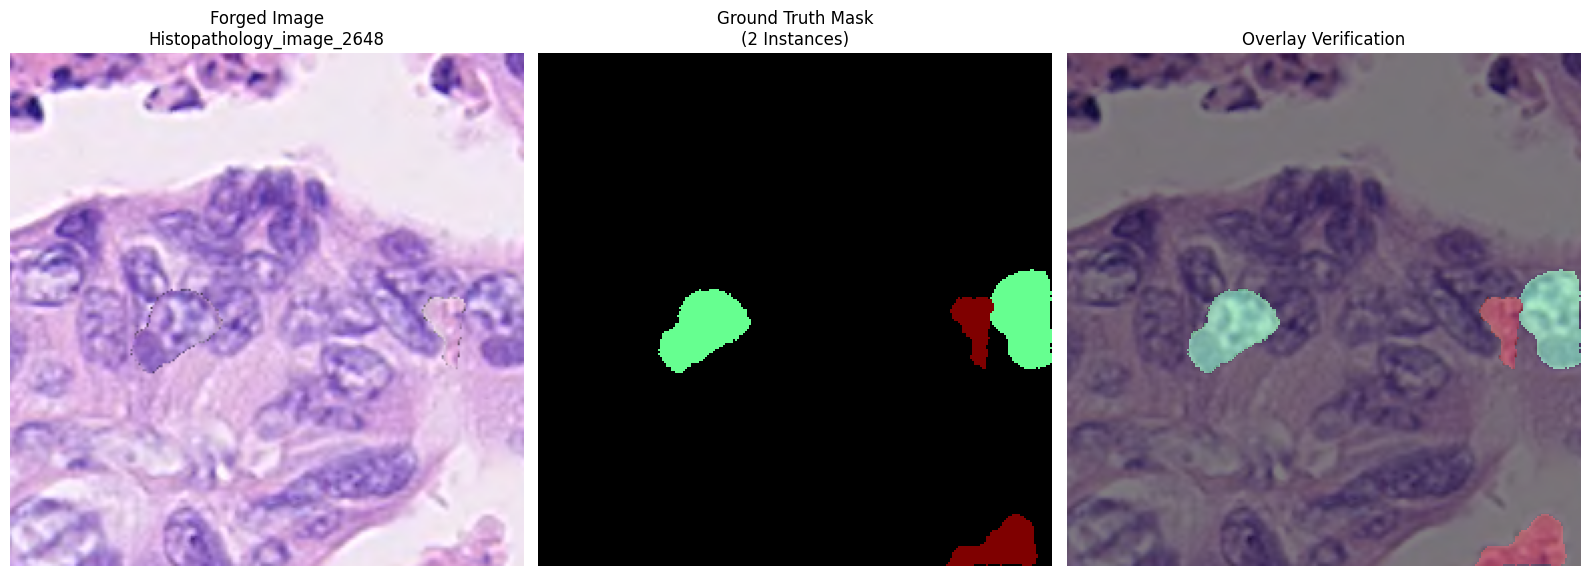

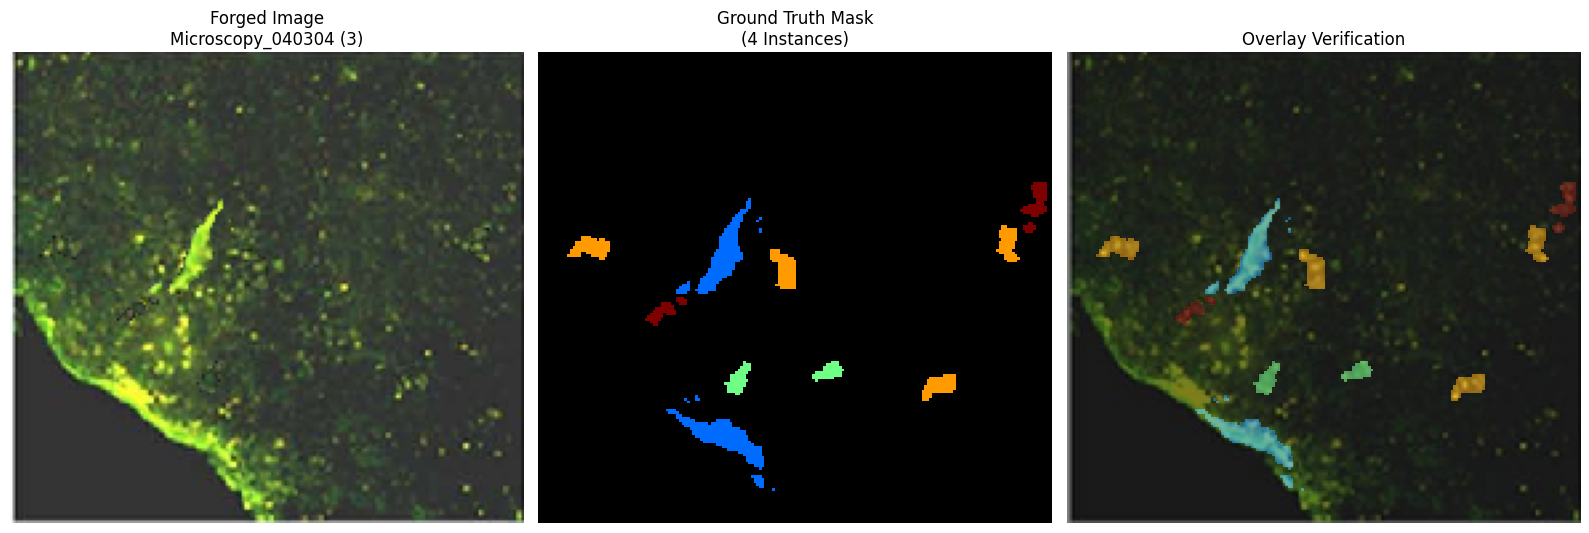

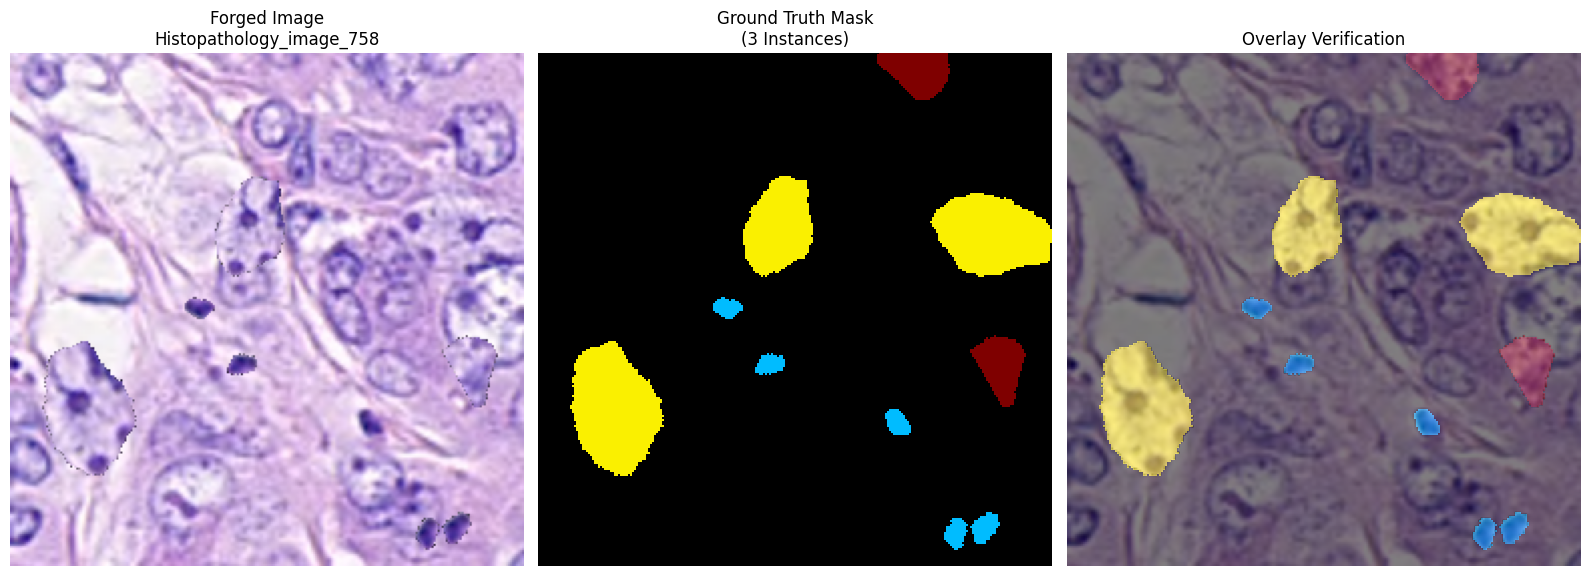

In [4]:
## orignal rle

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
import random

# ==============================================================================
# VISUALIZATION SCRIPT (HANDLES RAW MASKS)
# ==============================================================================

def visualize_generated_data(img_dir, mask_dir, num_samples=3):
    if not os.path.exists(img_dir):
        print(f"❌ Directory not found: {img_dir}")
        return

    files = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    if not files:
        print("❌ No images found.")
        return

    print(f"✅ Found {len(files)} images. Showing {num_samples} samples...\n")
    
    selected_files = random.sample(files, min(len(files), num_samples))

    for fname in selected_files:
        base_name = os.path.splitext(fname)[0]
        img_path = os.path.join(img_dir, fname)
        mask_path = os.path.join(mask_dir, f"{base_name}.npy")

        # 1. Load Image
        try:
            image = Image.open(img_path).convert("RGB")
            W, H = image.size
        except Exception as e:
            print(f"Error loading image {fname}: {e}")
            continue

        # 2. Load Mask Data
        if not os.path.exists(mask_path):
            print(f"Mask missing for {fname}")
            continue
            
        try:
            # Load the raw data
            mask_data = np.load(mask_path, allow_pickle=True)
            
            # --- CRITICAL FIX: DETECT RAW MASKS vs RLE ---
            full_mask = np.zeros((H, W), dtype=np.uint8)
            valid_instances = 0
            
            # CASE A: It is a raw mask array (N, H, W) or (H, W)
            # The debug showed shape (2, 4159, 2781), so this is likely the case.
            if mask_data.ndim >= 2 and np.issubdtype(mask_data.dtype, np.number) or mask_data.dtype == bool:
                
                # If shape is (H, W), treat as single instance
                if mask_data.ndim == 2:
                    if np.sum(mask_data) > 0:
                        full_mask[mask_data > 0] = 1
                        valid_instances = 1
                        
                # If shape is (N, H, W), iterate through instances
                elif mask_data.ndim == 3:
                    num_instances = mask_data.shape[0]
                    for i in range(num_instances):
                        instance = mask_data[i]
                        if np.sum(instance) > 0:
                            # Resize if necessary (though shape usually matches)
                            if instance.shape != (H, W):
                                # Basic resizing if dimensions mismatch (rare)
                                import cv2
                                instance = cv2.resize(instance.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
                                
                            full_mask[instance > 0] = i + 1
                            valid_instances += 1
            
            # CASE B: It is RLE strings (fallback code just in case)
            else:
                print(f"⚠️ Unexpected data format: {mask_data.shape}. Skipping RLE decode logic.")

        except Exception as e:
            print(f"Error processing {base_name}: {e}")
            continue

        # 3. Display
        plt.figure(figsize=(16, 6))

        # Plot 1: Image
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title(f"Forged Image\n{base_name}")
        plt.axis('off')

        # Plot 2: Mask
        plt.subplot(1, 3, 2)
        try:
            cmap = matplotlib.colormaps['jet'].copy()
        except AttributeError:
            cmap = plt.cm.get_cmap('jet').copy()
        cmap.set_under('black')
        
        # Determine Safe VMAX to avoid crash
        safe_vmax = max(full_mask.max(), 1.0)
        
        plt.imshow(full_mask, cmap=cmap, vmin=0.1, vmax=safe_vmax, interpolation='nearest')
        plt.title(f"Ground Truth Mask\n({valid_instances} Instances)")
        plt.axis('off')

        # Plot 3: Overlay
        plt.subplot(1, 3, 3)
        plt.imshow(image)
        plt.imshow(full_mask, cmap=cmap, vmin=0.1, vmax=safe_vmax, alpha=0.5, interpolation='nearest')
        plt.title("Overlay Verification")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# ==============================================================================
# RUN
# ==============================================================================
# Using raw strings (r"...") to handle Windows backslashes correctly
IMG_DIR = r"recodai-luc-scientific-image-forgery-detection\synthetic_forgery_dataset\forged\images"
MASK_DIR = r"recodai-luc-scientific-image-forgery-detection\synthetic_forgery_dataset\masks"

visualize_generated_data(IMG_DIR, MASK_DIR, num_samples=3)

In [62]:
import os
import numpy as np
import json
from PIL import Image
from tqdm import tqdm
import sys

# ==============================================================================
# 1. DECODING LOGIC (From your "Incorrect" Script)
# ==============================================================================
def rle_decode(mask_rle_input, shape):
    """
    Decodes the RLE string (JSON format [start, len, ...]) into a binary mask.
    Args:
        mask_rle_input: String or List containing RLE data.
        shape: (height, width) of the target image.
    """
    try:
        # Handle format variations (String vs List)
        if isinstance(mask_rle_input, str):
            if mask_rle_input == '-' or not mask_rle_input:
                return np.zeros(shape, dtype=np.uint8)
            mask_rle = json.loads(mask_rle_input)
        else:
            mask_rle = mask_rle_input

        # Create flat array
        img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        
        # Extract starts and lengths
        # The format is [start, length, start, length, ...]
        starts = np.array(mask_rle[0::2])
        lengths = np.array(mask_rle[1::2])
        
        # 1-based indexing to 0-based
        starts -= 1
        ends = starts + lengths
        
        # Set pixels
        for lo, hi in zip(starts, ends):
            # Boundary check to be safe
            if lo < 0: lo = 0
            if hi > len(img): hi = len(img)
            img[lo:hi] = 1
            
        # Reshape (Fortran order 'F' is standard for these RLEs)
        return img.reshape(shape, order='F')
        
    except Exception as e:
        print(f"Warning: RLE Decode error: {e}")
        return np.zeros(shape, dtype=np.uint8)

# ==============================================================================
# 2. CONVERSION WORKER
# ==============================================================================
def convert_rle_to_raw_masks(src_mask_dir, img_dir, dest_mask_dir):
    """
    Reads RLE-string .npy files, converts them to raw numpy arrays (N, H, W),
    and saves them to dest_mask_dir.
    """
    if not os.path.exists(src_mask_dir):
        print(f"❌ Source mask directory not found: {src_mask_dir}")
        return
    if not os.path.exists(img_dir):
        print(f"❌ Image directory not found (needed for dimensions): {img_dir}")
        return
        
    # Create destination folder
    os.makedirs(dest_mask_dir, exist_ok=True)
    
    # List files
    mask_files = [f for f in os.listdir(src_mask_dir) if f.endswith('.npy')]
    print(f"🔄 Found {len(mask_files)} masks to convert...")
    
    success_count = 0
    error_count = 0
    
    for mask_file in tqdm(mask_files, desc="Converting"):
        base_name = os.path.splitext(mask_file)[0]
        
        # Paths
        src_path = os.path.join(src_mask_dir, mask_file)
        dest_path = os.path.join(dest_mask_dir, mask_file)
        img_path = os.path.join(img_dir, f"{base_name}.png")
        
        # 1. Get Dimensions from Image
        if not os.path.exists(img_path):
            # Try .jpg if .png missing
            img_path = os.path.join(img_dir, f"{base_name}.jpg")
            if not os.path.exists(img_path):
                # print(f"⚠️ Image missing for {mask_file}, skipping...")
                error_count += 1
                continue
        
        try:
            with Image.open(img_path) as pil_img:
                W, H = pil_img.size
        except Exception as e:
            print(f"⚠️ Error reading image {base_name}: {e}")
            error_count += 1
            continue
            
        # 2. Load Source RLE
        try:
            rle_payload = np.load(src_path, allow_pickle=True)
            
            # Extract string content
            if rle_payload.shape == ():
                rle_content = rle_payload.item()
            else:
                rle_content = str(rle_payload)
                
            # Handle list of strings (if saved that way) or semicolon separated string
            rle_strings = []
            if isinstance(rle_content, str):
                rle_strings = rle_content.split(';')
            elif isinstance(rle_content, (list, np.ndarray)):
                 # If it's a list like ["RLE1", "RLE2"]
                rle_strings = rle_content
            
        except Exception as e:
            print(f"⚠️ Error loading/parsing npy {base_name}: {e}")
            error_count += 1
            continue
            
        # 3. Decode into (N, H, W) Array
        decoded_masks = []
        for rle_str in rle_strings:
            if not rle_str or rle_str == '-': 
                continue
            
            # Decode
            mask = rle_decode(rle_str, (H, W))
            
            # Only add if mask has pixels
            if np.sum(mask) > 0:
                decoded_masks.append(mask)
        
        if not decoded_masks:
            # If no valid masks, save an empty zeros array (H, W) or skip?
            # Saving empty array (1, H, W) of zeros is safer
            final_array = np.zeros((1, H, W), dtype=np.uint8)
        else:
            # Stack into (N, H, W)
            final_array = np.stack(decoded_masks, axis=0).astype(np.uint8)
            
        # 4. Save to Destination
        np.save(dest_path, final_array)
        success_count += 1

    print("\n✅ Conversion Complete.")
    print(f"   Success: {success_count}")
    print(f"   Errors/Skipped: {error_count}")
    print(f"   Saved to: {dest_mask_dir}")

# ==============================================================================
# 3. RUN IT
# ==============================================================================

# --- CONFIGURE PATHS HERE ---
WRONG_MASK_DIR = r"synthetic_forgery_dataset_04\masks"
IMG_DIR = r"synthetic_forgery_dataset_04\images"

# New folder where corrected masks will be saved
NEW_MASK_DIR = r"synthetic_forgery_dataset_04\masks_converted"

convert_rle_to_raw_masks(WRONG_MASK_DIR, IMG_DIR, NEW_MASK_DIR)

🔄 Found 12201 masks to convert...


Converting: 100%|██████████| 12201/12201 [08:54<00:00, 22.81it/s]


✅ Conversion Complete.
   Success: 12201
   Errors/Skipped: 0
   Saved to: synthetic_forgery_dataset_04\masks_converted
